In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('thesis')
import pickle as pkl
import pandas as pd

In [2]:
def get_linear_coeffs(snr):
    model = pkl.load(open(f"/avatar/vmehta/sfh_100_20260302_162622/noisy-training/snr{snr}_model.pkl", "rb"))
    return model['theta'][:,1:3]

wavs = np.load("/avatar/vmehta/sfh_100_20260302_162622/sfh_100_20260302_162622_wavelength.npy")

/tmp/ipykernel_1082415/3321108838.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  model = pkl.load(open(f"/avatar/vmehta/sfh_100_20260302_162622/noisy-training/snr{snr}_model.pkl", "rb"))


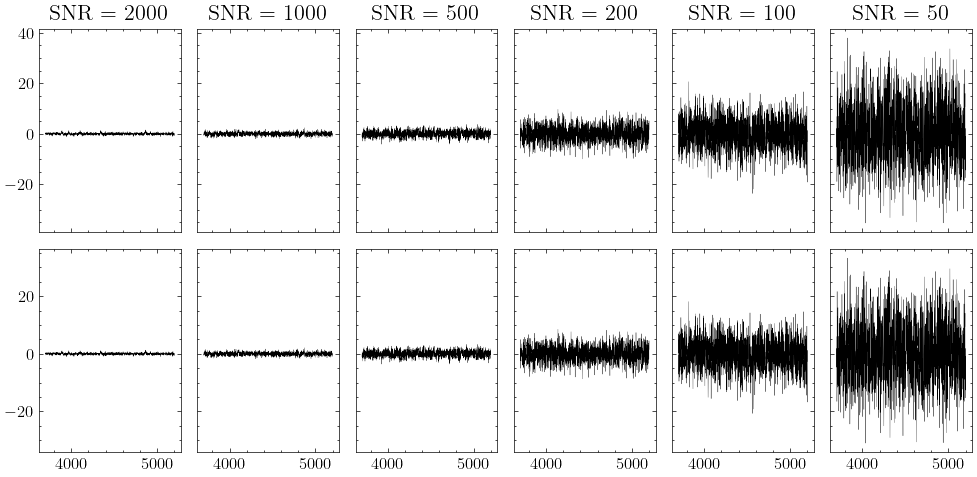

In [7]:
fig, ax = plt.subplots(2, 6, figsize=(10,5), sharex=True, sharey='row')

for n, s in enumerate([2000, 1000, 500, 200, 100, 50]):
    for i in range(2):
        ax[i, n].plot(wavs, get_linear_coeffs(s)[:,i], linewidth=0.2, color='k')

ax[0,0].set_title("SNR = 2000")
ax[0,1].set_title("SNR = 1000")
ax[0,2].set_title("SNR = 500")
ax[0,3].set_title("SNR = 200")
ax[0,4].set_title("SNR = 100")
ax[0,5].set_title("SNR = 50")

plt.tight_layout()
plt.show()

In [8]:
def get_labels(snr):
    model = 10**(np.load(f"/avatar/vmehta/sfh_500_20260226_085303/noisy-training/snr{snr}_pred.npy"))
    return model
true = 10**(np.load("/avatar/vmehta/sfh_500_20260226_085303/noisy-training/snr2000_true.npy"))

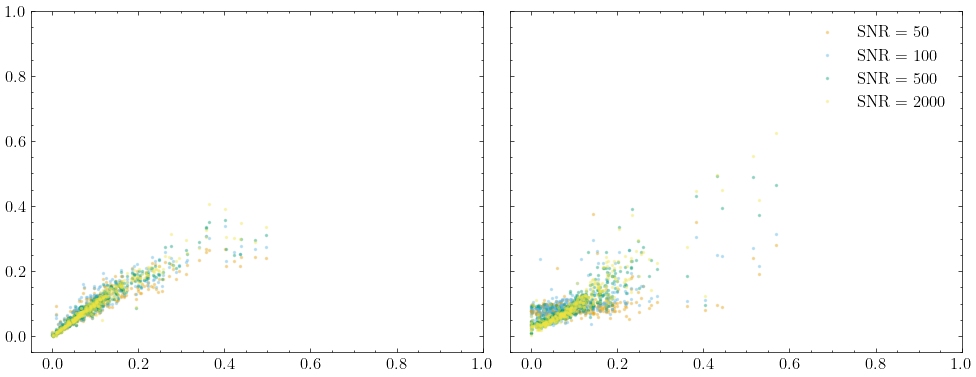

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10,4), sharex=True, sharey=True)

for s in [50, 100, 500, 2000]:
    for i in range(2):
        ax[i].plot(true[:,i], get_labels(s)[:,i], '.', alpha=0.3, markersize=3)

ax[0].set_xlim(-0.05,1)
ax[0].set_ylim(-0.05,1)
ax[1].legend(["SNR = 50", "SNR = 100", "SNR = 500", "SNR = 2000"], loc='upper right')

plt.tight_layout()

In [15]:
f = np.load('/home/vmehta/honours-project/code/data/sfh_twobins_spectra.npy')
f

array([[8.51079209e-14, 8.56531898e-14, 8.56852001e-14, ...,
        6.80685613e-14, 6.82207275e-14, 6.85323590e-14],
       [2.15071712e-15, 2.22481066e-15, 2.21341201e-15, ...,
        4.21332854e-15, 4.24209890e-15, 4.28862035e-15]], shape=(2, 1667))

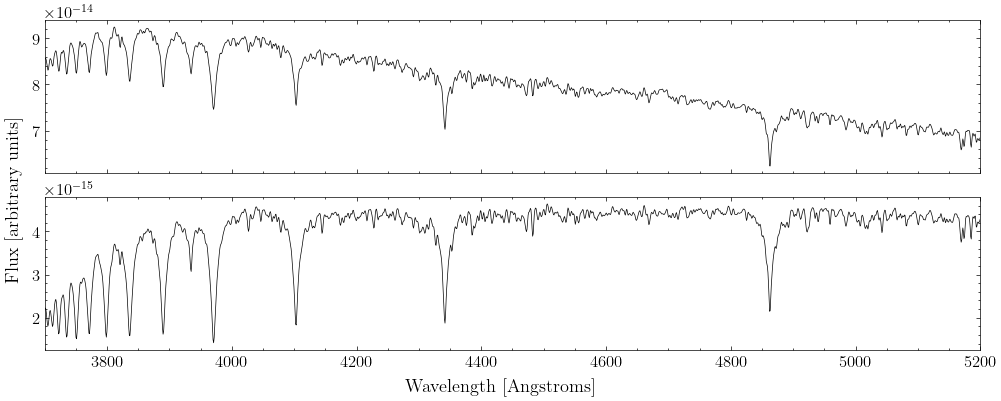

In [21]:

fig, ax = plt.subplots(2, 1, figsize=(10,4), sharex=True, constrained_layout=True)
for i, s in enumerate(f):
    ax[i].plot(wavs, s, 'k', linewidth=0.5)

ax[0].set_xlim(3700,5200)
fig.supylabel('Flux [arbitrary units]')
fig.supxlabel('Wavelength [Angstroms]')

#plt.savefig('/home/vmehta/honours-project/thesis/figures/sfh_averages.pdf', format='pdf')
plt.show()